# 1 — Quickstart: one VMC run, start to finish

Five non-interacting particles in a 1-D harmonic trap. The exact ground-state energy is
`N * omega / 2 = 2.5`, so there is something to check against.

The pattern for every run: **build objects, hand them to `VMC`, call `.run()`.**

In [1]:
# Small on purpose, so they stay on the CPU and leave your GPU free for real runs.
import os
os.environ.setdefault("JAX_PLATFORMS", "cuda")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import optax

## The ansatz

`LogWavefunction` composes the pieces and sums them in log space:

    log|psi(x)| = network(transform(x)) [+ envelope(x)] [+ jastrow(x)]

The envelope is load-bearing. A bare tanh MLP saturates to a constant `log|psi|` at
large `|x|`, so `|psi|^2` has flat tails, walkers random-walk to infinity and the energy
diverges. The Gaussian envelope makes the state normalisable.

In [2]:
from qvarnet.ansatz.compose import LogWavefunction
from qvarnet.ansatz.envelopes import GaussianEnvelope
from qvarnet.ansatz.mlp import MLP

n_particles, omega = 5, 1.0
E_exact = n_particles * omega / 2

psi = LogWavefunction(
    network=MLP(hidden=[32, 32], output_dim=1),
    envelope=GaussianEnvelope(),
)
psi

LogWavefunction(
    # attributes
    network = MLP(
        # attributes
        architecture = None
        hidden = [32, 32]
        output_dim = 1
        hidden_activation = tanh
        kernel_init = init
        bias_init = zeros
        beta = 1.0
        has_output_activation = False
    )
    transform = None
    n_particles = None
    n_dim = None
    envelope = GaussianEnvelope(
        # attributes
        init = 0.1
    )
    jastrow = None
)

## The run

The two configs answer different questions: `SamplingConfig` is *how long the chains
run*, the sampler (default `Metropolis()`) is *how the walkers move*. One knob, one owner.

A cosine schedule on the learning rate is doing real work here — see the diagnostics
section below for what happens without one.

In [3]:
import tempfile
from qvarnet import VMC, SamplingConfig, TrainingConfig
from qvarnet.physics.hamiltonian.continuous import HarmonicOscillatorHamiltonian

n_epochs = 80000

result = VMC(
    shape=(20000, n_particles),               # (n_chains, n_particles * n_dim)
    model=psi,
    optimizer=optax.adam(optax.cosine_decay_schedule(5e-3, n_epochs, alpha=0.05)),
    hamiltonian=HarmonicOscillatorHamiltonian(omega=omega),
    training_config=TrainingConfig(
        n_epochs=n_epochs,
        rng_seed=0,
        checkpoint_path=tempfile.mkdtemp(),
        is_update_step_size=True,           # retune the MH step toward 50% acceptance
        print_summary=False,
    ),
    sampler_params=SamplingConfig(
        step_size=0.5, chain_length=21,
        thermalization_steps=20, thinning_factor=1,
    ),
).run()

summary = result.summary()

── training summary ────────────────────────────────────────
epochs ran       : 80000   (5m 09.5s wall, 1282 parameters)
final epoch      : E = 2.500001 ± 3.87e-08   σ_E = 0.0000
best epoch (79971) : E = 2.500001 ± 1.47e-08   σ_E = 0.0000
acceptance (tail): 0.500
best snapshot    : epoch 79971 (select metric = 2.08456e-06; 3 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


## The trace

`result.history` is a `MetricsHistory`: per-epoch scalars, retrieved as arrays.
`history.keys()` tells you which fields this run recorded.

In [4]:
print(sorted(result.history.keys()))

['E_chain', 'acceptance_rate', 'cm_mean', 'cm_std', 'energy', 'error_of_mean', 'grad_norm', 'std', 'step', 'step_size', 'theta_ratio', 'wall_time']


tail energy 2.5000   exact 2.5


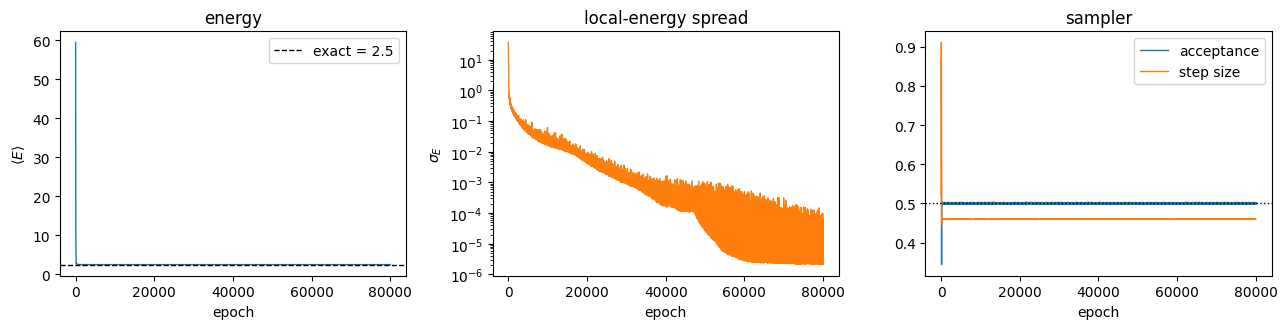

In [5]:
energy = result.history.get("energy")
std = result.history.get("std")
acceptance = np.array([np.mean(r) for r in result.history.get("acceptance_rate")])
step_size = result.history.get("step_size")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

ax[0].plot(energy, lw=1)
ax[0].axhline(E_exact, color="k", ls="--", lw=1, label=f"exact = {E_exact}")
ax[0].set(xlabel="epoch", ylabel=r"$\langle E \rangle$", title="energy")
ax[0].legend()

ax[1].plot(std, lw=1, color="tab:orange")
ax[1].set(xlabel="epoch", ylabel=r"$\sigma_E$", title="local-energy spread", yscale="log")

ax[2].plot(acceptance, lw=1, label="acceptance")
ax[2].plot(step_size, lw=1, label="step size")
ax[2].axhline(0.5, color="k", ls=":", lw=1)
ax[2].set(xlabel="epoch", title="sampler")
ax[2].legend()
fig.tight_layout()

print(f"tail energy {np.mean(energy[-50:]):.4f}   exact {E_exact}")

`sigma_E` is the more honest signal than the energy. It is the spread of the *local*
energy, exactly zero for an eigenstate — so it measures how close the ansatz is to being
one, and it keeps falling after the energy curve looks flat.

## Is it converged?

`diagnose()` runs three independent referees. Do not be surprised that this run does not
pass: the energy is within ~1% of exact, but it is still measurably **descending**, and
referee 1 is built to notice that. Notebook 4 covers what each referee measures.

In [ ]:
verdict = result.diagnose()

That is the right answer, not a broken one. A decreasing curve that looks flat by eye
is usually still improving, and "looks flat" is exactly the judgement the referees exist
to replace.

## What you get back

Everything needed to resume or post-analyse the run:

In [ ]:
print("best params (by lowest std):", type(result.best_params()).__name__)
print("retained snapshots:          ", len(result.snapshots))
print("final walker positions:      ", np.asarray(result.final_positions).shape)
print("final adapted step size:      %.4f" % result.final_step_size)

best params (by lowest std): dict
retained snapshots:           3
final walker positions:       (512, 5)
final adapted step size:      0.4594


Feeding `final_positions` and `final_step_size` into a second run resumes from
equilibrated walkers instead of re-thermalising — `qvarnet.recipes` does exactly that
through its `prev_result=` argument. Notebook 3 picks the parameters up for measurement.